# Creative Writing - 1. Alignment Metrics

## Setup

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

SCORE_MIN, SCORE_MAX = 0, 20

POSITIVE_CATEGORIES = [
    "Adherence to Instructions", "Believable Character Actions", "Nuanced Characters",
    "Consistent Voice / Tone of Writing", "Imagery and Descriptive Quality", "Elegant Prose",
    "Emotionally Engaging", "Emotionally Complex", "Coherent",
    "Well-earned Lightness or Darkness", "Sentences Flow Naturally",
    "Overall Reader Engagement", "Overall Impression",
]
NEGATIVE_CATEGORIES = [
    "Meandering", "Weak Dialogue", "Tell-Don't-Show", "Unsurprising or Uncreative",
    "Amateurish", "Purple Prose", "Overwrought",
    "Incongruent Ending Positivity", "Unearned Transformations",
]
ALL_CATEGORIES = POSITIVE_CATEGORIES + NEGATIVE_CATEGORIES
POS_COLS = [f"{c}_score" for c in POSITIVE_CATEGORIES]
NEG_COLS = [f"{c}_score" for c in NEGATIVE_CATEGORIES]
ALL_COLS = POS_COLS + NEG_COLS

def pretty_model(stem: str) -> str:
    return stem.replace("_result", "")

## 1. Load data

In [2]:
ref = pd.read_csv(RESULTS_DIR / BASELINE_FILE)
KEYS = ["index", "model"]

evaluator_dfs = {}
for p in sorted(RESULTS_DIR.glob("*_result.csv")):
    if "claude" in p.name:
        continue
    name = pretty_model(p.stem)
    ev = pd.read_csv(p)
    m = pd.merge(ev, ref, on=KEYS, suffixes=("_ev", "_ref"), how="inner")
    evaluator_dfs[name] = m

print(f"Baseline: {BASELINE_FILE}  ({len(ref)} rows)")
for name, df in evaluator_dfs.items():
    print(f"  {name}: {len(df)} rows")

Baseline: claude_sonnet_4.6_result.csv  (767 rows)
  Llama-3.2-3B-Instruct: 767 rows
  NVIDIA-Nemotron-3-Nano-4B-BF16: 767 rows
  Qwen3-4B-Instruct-2507: 767 rows
  Qwen3.5-4B: 767 rows
  gemma-4-E2B-it: 767 rows
  gemma-4-E4B-it: 767 rows


## 2. Alignment metrics

Per-model MAE, RMSE, Spearman ρ, Kendall τ vs Claude Sonnet 4.6 baseline.

In [3]:
summary_rows = []

for name, m in evaluator_dfs.items():
    pos_diffs, neg_diffs, all_diffs = [], [], []
    all_ev, all_ref_vals = [], []

    for col in ALL_COLS:
        ev_s  = m[f"{col}_ev"].to_numpy(dtype=float)
        ref_s = m[f"{col}_ref"].to_numpy(dtype=float)
        mask  = ~(np.isnan(ev_s) | np.isnan(ref_s))
        diff  = ev_s[mask] - ref_s[mask]
        all_diffs.append(diff)
        all_ev.extend(ev_s[mask])
        all_ref_vals.extend(ref_s[mask])
        if col in POS_COLS:
            pos_diffs.append(diff)
        else:
            neg_diffs.append(diff)

    pos = np.concatenate(pos_diffs)
    neg = np.concatenate(neg_diffs)
    all_d = np.concatenate(all_diffs)
    rho, _ = stats.spearmanr(all_ev, all_ref_vals)
    tau, _ = stats.kendalltau(all_ev, all_ref_vals)

    summary_rows.append({
        "Model":         name,
        "Pos MAE":       round(float(np.mean(np.abs(pos))),  3),
        "Neg MAE":       round(float(np.mean(np.abs(neg))),  3),
        "Overall MAE":   round(float(np.mean(np.abs(all_d))), 3),
        "RMSE":          round(float(np.sqrt(np.mean(all_d**2))), 3),
        "Spearman ρ":    round(float(rho), 3),
        "Kendall τ":     round(float(tau), 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Overall MAE").reset_index(drop=True)
display(summary_df)

print("\nLaTeX table rows:")
for _, r in summary_df.iterrows():
    print(f"{r['Model']:<30} & {r['Pos MAE']:.3f} & {r['Neg MAE']:.3f} & {r['RMSE']:.3f} & {r['Spearman ρ']:.3f} & {r['Kendall τ']:.3f} \\\\")

,Model,Pos MAE,Neg MAE,Overall MAE,RMSE,Spearman ρ,Kendall τ
0,Qwen3.5-4B,1.744,1.970,1.836,2.361,0.861,0.683
1,gemma-4-E2B-it,2.044,3.139,2.492,3.164,0.804,0.610
2,gemma-4-E4B-it,2.993,2.880,2.947,3.424,0.823,0.650
3,NVIDIA-Nemotron-3-Nano-4B-BF16,2.056,4.397,3.014,4.066,0.696,0.498
4,Qwen3-4B-Instruct-2507,3.527,2.400,3.066,3.573,0.818,0.619
5,Llama-3.2-3B-Instruct,4.002,3.817,3.926,5.218,0.655,0.501



LaTeX table rows:
Qwen3.5-4B                     & 1.744 & 1.970 & 2.361 & 0.861 & 0.683 \\
gemma-4-E2B-it                 & 2.044 & 3.139 & 3.164 & 0.804 & 0.610 \\
gemma-4-E4B-it                 & 2.993 & 2.880 & 3.424 & 0.823 & 0.650 \\
NVIDIA-Nemotron-3-Nano-4B-BF16 & 2.056 & 4.397 & 4.066 & 0.696 & 0.498 \\
Qwen3-4B-Instruct-2507         & 3.527 & 2.400 & 3.573 & 0.818 & 0.619 \\
Llama-3.2-3B-Instruct          & 4.002 & 3.817 & 5.218 & 0.655 & 0.501 \\


## 3. Per-category MAE heatmap

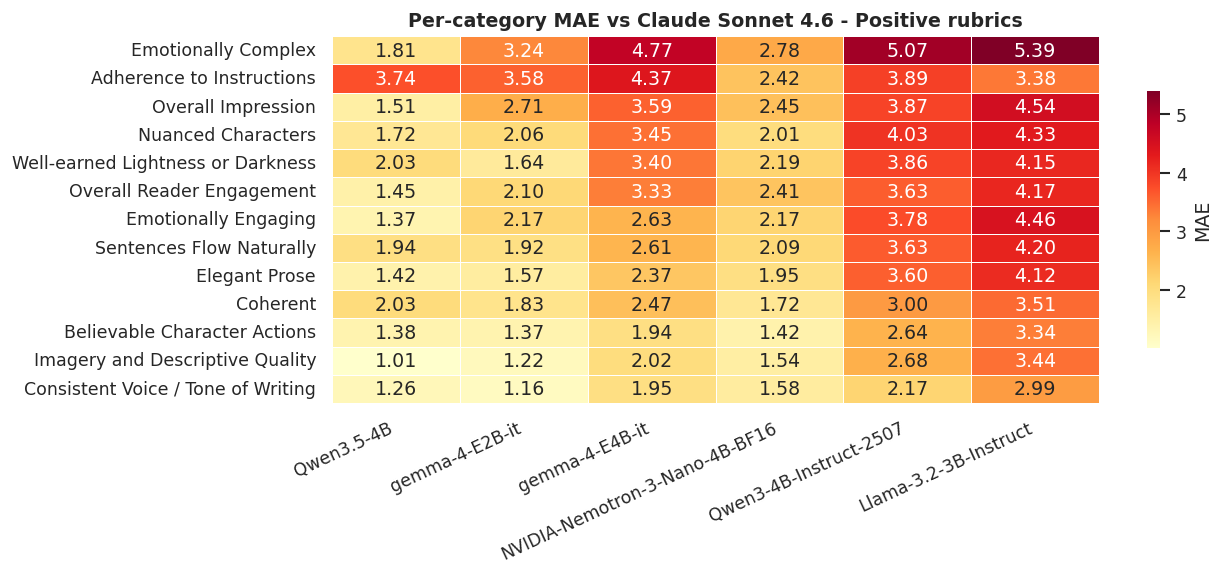

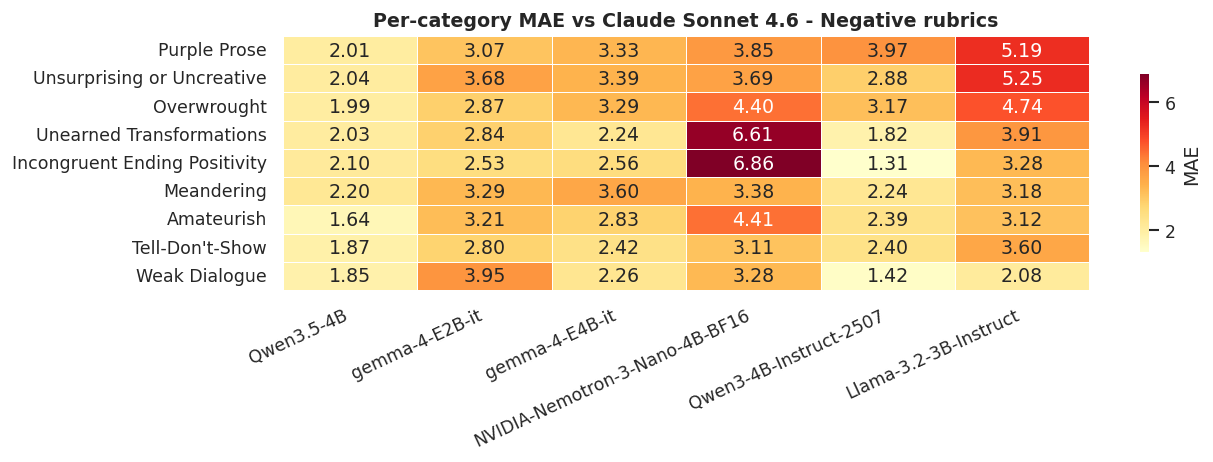

In [4]:
per_cat_rows = []
model_order = summary_df["Model"].tolist()

for name, m in evaluator_dfs.items():
    for col in ALL_COLS:
        ev_s  = m[f"{col}_ev"].to_numpy(dtype=float)
        ref_s = m[f"{col}_ref"].to_numpy(dtype=float)
        mask  = ~(np.isnan(ev_s) | np.isnan(ref_s))
        diff  = ev_s[mask] - ref_s[mask]
        per_cat_rows.append({
            "model":  name,
            "rubric": col.replace("_score", ""),
            "type":   "positive" if col in POS_COLS else "negative",
            "mae":    float(np.mean(np.abs(diff))),
        })

per_cat_df = pd.DataFrame(per_cat_rows)

for cat_type, title in [("positive", "Positive rubrics"), ("negative", "Negative rubrics")]:
    sub    = per_cat_df[per_cat_df["type"] == cat_type]
    pivot  = sub.pivot(index="rubric", columns="model", values="mae")[model_order]
    pivot  = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    h = max(4, len(pivot) * 0.38)
    fig, ax = plt.subplots(figsize=(11, h))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
                linewidths=0.4, cbar_kws={"label": "MAE", "shrink": 0.7})
    ax.set_title(f"Per-category MAE vs Claude Sonnet 4.6 - {title}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()